Практический пример модели Линейной pегрессии: Предсказание Цены Дома

In [ ]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import matplotlib.pyplot as plt

In [ ]:
# 1. Сгенерируем искусственные данные для примера
np.random.seed(0)  # для воспроизводимости
n_samples = 100
площадь = np.random.randint(50, 200, n_samples)  # Площадь дома (в кв. метрах)
цена = 1000 * площадь + np.random.normal(0, 50000, n_samples) # Цена (в долларах) + случайный шум

In [ ]:
# Создадим DataFrame
df = pd.DataFrame({'площадь': площадь, 'цена': цена})
df

,площадь,цена
0,97,194964.794539
1,167,157078.715196
2,117,133526.720282
3,153,81208.579698
4,59,60376.415856
...,...,...
95,188,200639.262832
96,164,163053.129089
97,93,58465.847106
98,177,216988.082258


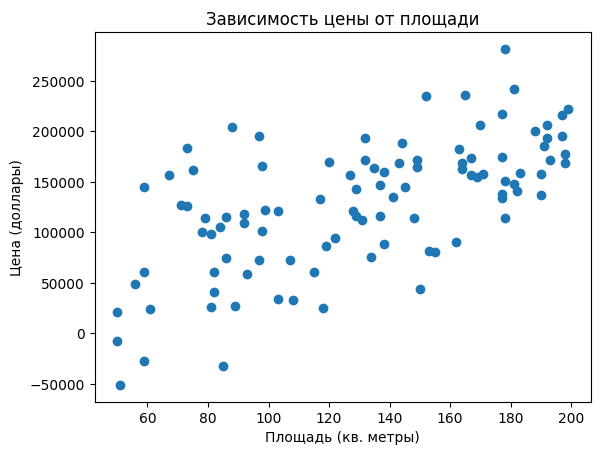

In [ ]:
# Визуализируем данные
plt.scatter(df['площадь'], df['цена'])
plt.xlabel('Площадь (кв. метры)')
plt.ylabel('Цена (доллары)')
plt.title('Зависимость цены от площади')
plt.show()

In [ ]:
# 2. Подготовим данные для обучения
X = df[['площадь']]  # Независимая переменная (признак)
y = df['цена']  # Зависимая переменная (целевая переменная)

# 3. Разделим данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.shape

(80, 1)

In [ ]:
X_test.shape

(20, 1)

In [ ]:
# 4. Создадим модель линейной регрессии
model = LinearRegression()

# 5. Обучим модель на обучающей выборке
model.fit(X_train, y_train)

# 6. Сделаем предсказания на тестовой выборке
y_pred = model.predict(X_test)

# 7. Оценим качество модели
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Среднеквадратичная ошибка (MSE): {mse:.2f}")
print(f"Корень из среднеквадратичной ошибки (RMSE): {rmse:.2f}")
print(f"Коэффициент детерминации (R-squared): {r2:.2f}")

# 8. Выведем коэффициенты модели
print(f"Коэффициент b0 (intercept): {model.intercept_:.2f}")
print(f"Коэффициент b1 (slope): {model.coef_[0]:.2f}")



Среднеквадратичная ошибка (MSE): 3198670483.33
Корень из среднеквадратичной ошибки (RMSE): 56556.79
Коэффициент детерминации (R-squared): 0.23
Коэффициент b0 (intercept): 6144.21
Коэффициент b1 (slope): 959.64


для просмотра результата

In [ ]:
def create_comparison_df(X_test, y_test, y_pred):

    # 1. Преобразование в DataFrame (при необходимости)
    if not isinstance(X_test, pd.DataFrame):
        X_test = pd.DataFrame(X_test)  # Преобразуем X_test в DataFrame, если это массив
    if not isinstance(y_test, pd.Series):
        y_test = pd.Series(y_test)  # Преобразуем y_test в Series, если это массив

    # 2. Убедимся, что индексы совпадают (Важно!)
    y_test = y_test.reset_index(drop=True)  # Сбросим индекс, если это необходимо
    X_test = X_test.reset_index(drop=True)
    y_pred = np.array(y_pred)  #  Обязательно преобразуем y_pred в np array

    # 3. Создадим DataFrame
    df = X_test.copy() # Копируем X_test, чтобы не изменять исходный DataFrame
    df['y_true'] = y_test #  Ошибки связаны с тем, что индексы не совпадали
    df['y_pred'] = y_pred # Добавляем предсказанные значения

    return df

In [ ]:
# 3. Создадим DataFrame для сравнения
df_comparison = create_comparison_df(X_test, y_test, y_pred)
df_comparison

,площадь,y_true,y_pred
0,50,-7814.073413,54125.964953
1,152,235113.117194,152008.742213
2,150,43874.399456,150089.472071
3,155,80333.002089,154887.647427
4,182,140956.808537,180797.794349
5,103,34078.495209,104986.623726
6,129,142849.845255,129937.135576
7,119,86414.236199,120340.784864
8,190,157454.356393,188474.874918
9,97,194964.794539,99228.813298


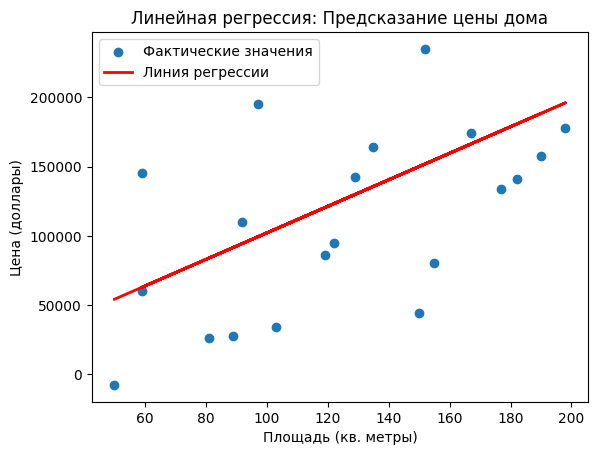

In [ ]:
# 9. Визуализируем результаты (линию регрессии)
plt.scatter(X_test, y_test, label='Фактические значения')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Линия регрессии')
plt.xlabel('Площадь (кв. метры)')
plt.ylabel('Цена (доллары)')
plt.title('Линейная регрессия: Предсказание цены дома')
plt.legend()
plt.show()